### Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import itertools
from math import e
from datetime import datetime, timedelta
import glob
import metpy.calc as mpcalc
from metpy.units import units
from sklearn.cluster import KMeans
import warnings; warnings.simplefilter('ignore')
from matplotlib.dates import date2num, DateFormatter
import matplotlib.dates as mdates
import matplotlib

In [2]:
from palettable.cartocolors.qualitative import Prism_8
from palettable.cartocolors.qualitative import Safe_10
from palettable.matplotlib import Viridis_10
from palettable.colorbrewer.diverging import PRGn_4
cluster_c = PRGn_4.mpl_colors
cluster_colors = cluster_c[2], cluster_c[0], cluster_c[3], cluster_c[1] ##4

viridis = Viridis_10.mpl_colors
c_l= [viridis[7], viridis[2],viridis[4],viridis[8], viridis[6]]
c_v = [c_l[3], c_l[0], c_l[4], c_l[2], c_l[1], viridis[1], viridis[0]]
color_cb = Safe_10.mpl_colors
prism = Prism_8.mpl_colors
blue = prism[1]
green = prism[3]
purple = prism[0]
red = prism[7]
orange = prism[6]
yellow = prism[5]
gray = "#303039"
color_list = [blue, green, purple, red, orange, yellow, gray]
style = "/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle"
plt.style.use(style)

Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 15 ("xtick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 16 ("ytick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 27 ('axes.edgecolor:222222')


In [3]:
dataPath = (
    "/Users/cneumaie/OneDrive - Colostate/Research/Drone_Profiles/00_Data/"
)

figPath = "/Users/cneumaie/OneDrive - Colostate/Research/Drone_Profiles/02_Figures/"

## Get log 

In [4]:
log = pd.read_csv(f"{dataPath}CP_prof_log_BACS2_v15duv_CPpairs_orig.csv", parse_dates = True)
# log = pd.read_csv(f"{dataPath}prof_log_v16_airdata_id_v4.csv", parse_dates=True)

In [5]:
log.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'index', 'Date', 'IOP',
       'Type', 'Flight', 'profid', 'starttime', 'endtime', 'Aspirated',
       'Unaspirated', 'count', 'starttime_ad', 'Condition',
       '3cluster_minmax_CPpairs', '4cluster_minmax_CPpairs', 'pre-CP_Tdiff',
       'pre-CP_MRdiff', '3cluster_minmax_CPonly', '4cluster_minmax_CPonly',
       'CP_id', 'onset_time', 'delta_time', 'min dT', 'max dMR', 'PS',
       'prev_CP_time', 'dT', 'dMR', 'dwspeed', 'duv', 'dBZ', 'LCL', 'PW',
       'Sfc-3km_LR', 'VPD', 'Sfc-350m_LR', 'Sfc-LCL_LR'],
      dtype='object')

## Functions for reading in iMet files and processing the data

In [6]:
def rh_from_dewpt(TD, T):
    return 100*(np.exp((17.625*TD)/(243.04+TD))/np.exp((17.625*T)/(243.04+T))) 

In [7]:
def correct_humidity(imet_dataset):
    '''bias correct the RH measurment on the imet sensor'''
    im = imet_dataset
    dps = mpcalc.dewpoint_from_relative_humidity((im['Temp_RH'].values)*units("degC"),
                                 (im['RH'].values)/100.0)
    im['Dewpoint'] = np.array(dps)
    new_rh_cor = rh_from_dewpt(im['Dewpoint'], im['Temp'])
    im['Recalc_RH'] = new_rh_cor
    mx_ratio = mpcalc.mixing_ratio_from_relative_humidity((im["P"].values)*units("hPa"), (im["Temp"].values)*units("degC"), 
                                               im["RH"].values/100).to('g/kg')
    im["Mixing_ratio(g/kg)"] = mx_ratio

    return im

In [8]:
def clean_imet_data(
    path,
    imetCols=[
        "XQ-iMet-XQ Pressure",
        "XQ-iMet-XQ Air Temperature",
        "XQ-iMet-XQ Humidity",
        "XQ-iMet-XQ Humidity Temp",
        "XQ-iMet-XQ Date",
        "XQ-iMet-XQ Time",
        "XQ-iMet-XQ Longitude",
        "XQ-iMet-XQ Latitude",
        "XQ-iMet-XQ Altitude",
        "XQ-iMet-XQ Sat Count",
    ],
    imetnewCols=[
        "P",
        "Temp",
        "RH",
        "Temp_RH",
        "Date",
        "Time",
        "Lon",
        "Lat",
        "Alt",
        "SatCount",
    ],
):
    df = pd.read_csv(path, parse_dates=True)
    df = df[imetCols]
    df.columns = imetnewCols

    df = df[df.Date.str[:4] == "2023"]
    df = df[df.Date.str[8:10] != "00"]

    df = df[df.SatCount > 0]

    df["Datetime"] = pd.to_datetime(df.Date + " " + df.Time)
    df_2 = correct_humidity(df)
    Temp_K = (df_2["Temp"].values+273.15)*units("K")
    df_2["Theta"] = mpcalc.potential_temperature((df_2["P"].values)*units("hPa"), Temp_K)
    df_2["Theta_v"] = mpcalc.virtual_potential_temperature((df_2["P"].values)*units("hPa"),Temp_K,df_2["Mixing_ratio(g/kg)"].values*units("g/kg"))
    df_2["T_v(K)"] = mpcalc.virtual_temperature(Temp_K,df_2["Mixing_ratio(g/kg)"].values*units("g/kg"))
    df_2["T_v(C)"] = df_2["T_v(K)"].values-273.15

    return df_2

In [9]:
def convert_datetime_log(input_datetime):
    '''converts datetime into the format required for getting
    the corresponding airdata log for each flight'''
    
    # Parse the input string into a datetime object
    dt = datetime.strptime(input_datetime, "%Y-%m-%d %H:%M:%S")
    
    # Format the day with the ordinal suffix
    day = dt.day
    if 10 <= day % 100 <= 20:  # Special case for teens
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(day % 10, "th")
    day_with_suffix = f"{day}{suffix}"
    
    # Format the datetime into the desired string
    output_datetime = dt.strftime(f"%b-{day_with_suffix}-%Y-%I-%M%p")
    

    return output_datetime, dt,day_with_suffix

In [10]:
def get_airdata(input_datetime):
    '''gets airdata converted log for the selected flight'''
    converted_datetime, dt,day_with_suffix = convert_datetime_log(input_datetime)
    airdataPath = f"{dataPath}/Converted Logs/Pileus Jr"
    try:
        airdata_log = pd.read_csv(f"{airdataPath}/{converted_datetime}-Flight-Airdata.csv")
        return airdata_log
    except:
            for i in range(1,7):
                dt_forward = dt + timedelta(minutes=i)
                forward_datetime = dt_forward.strftime(f"%b-{day_with_suffix}-%Y-%I-%M%p")
                try:
                    airdata_log = pd.read_csv(f"{airdataPath}/{forward_datetime}-Flight-Airdata.csv")
                    return airdata_log
                except:
                    continue
            for i in range(1,7):
                dt_backward = dt - timedelta(minutes=i)
                backward_datetime = dt_backward.strftime(f"%b-{day_with_suffix}-%Y-%I-%M%p")
                try:
                    airdata_log = pd.read_csv(f"{airdataPath}/{backward_datetime}-Flight-Airdata.csv")
                    return airdata_log
                except:
                    continue
            print("converted log not found")

## Summarize profiles by manual identification

In [11]:
envir = []
pre_CP = []
CP = []
post_CP = []
other = []
envir_df = pd.DataFrame()
pre_CP_df = pd.DataFrame()
CP_df = pd.DataFrame()
post_CP_df = pd.DataFrame()
other_df = pd.DataFrame()

z_interp = np.arange(5,351,3)
kmeans_list = []
kmeans_list_norm = []
T_mean_list = []
T_list = []

MR_list = []
km_list_theta = []

km_list_MR = []
km_list_Tv = []
km_list_THv = []
km_list_THv_2 = []
z_list = []

ps_list = []
label_list = []
leg_list = []
cp_list = []
iop_list = []


for IOP in range(16,28):
    # Select flight
    log_IOP = log[log["IOP"] == IOP]
    for flight in np.unique(log_IOP.Flight):
        flt = log[(log["IOP"]==IOP) & (log["Flight"] == flight)].reset_index()
        # read unaspirated imet
        uPath = f"{dataPath}/imet/{flt.Unaspirated[0]}-{pd.to_datetime(flt.Date[0]).strftime('%Y%m%d')}.csv"
        u = clean_imet_data(uPath)
        u["Alt_AGL"] = u["Alt"]-1661
        # use manual takeoff/landing times as initial guess
        u = u[(u.Datetime >= flt.starttime.iloc[0]) & (u.Datetime <= flt.endtime.iloc[-1])]
        u = u.reset_index()
        
        # get the converted air data drone log
        airdata_log = get_airdata(flt.starttime_ad[0])
        
        #convert datetime column to datetime format
        airdata_log["datetime(utc)"] = pd.to_datetime(airdata_log["datetime(utc)"])
        
        ### select only the times in the flight for the drone log
        airdata_log = airdata_log[(airdata_log["datetime(utc)"] >= flt.starttime.iloc[0]) & (airdata_log["datetime(utc)"] <= flt.endtime.iloc[-1])]


        
        # Select only numeric columns for aggregation
        numeric_cols = airdata_log.select_dtypes(include="number")
        # create a new drone log dataframe with only datetime and numeric columns for the flight
        numbers_ad_log = pd.concat([airdata_log["datetime(utc)"],numeric_cols], axis=1)
        # take the mean of the drone log data by second to match the timeseries of the iMet data
        ad_log_mean = numbers_ad_log.groupby("datetime(utc)").mean().reset_index()
        # Convert height to m
        ad_log_mean["height_AGL(m)"] = ad_log_mean['height_above_ground_at_drone_location(feet)']*0.3048
        # add drone height to iMet dataframe
        u["Height_AGL"] = ad_log_mean["height_AGL(m)"]
        asc_log = flt[flt["Type"] == "ascending"]
        dsc_log = flt[flt["Type"] == "descending"]
        press_list = []

        
        for leg in range(len(dsc_log.index)):
 
            a = u[(u.Datetime >= asc_log.starttime.iloc[leg]) & (u.Datetime <= asc_log.endtime.iloc[leg])]
            d = u[(u.Datetime >= dsc_log.starttime.iloc[leg]) & (u.Datetime <= dsc_log.endtime.iloc[leg])]
            a["ascent_flag"] = True
            d["ascent_flag"] = False
            a["normT"] = a.Temp-a.Temp.mean()
            d["normT"] = d.Temp-d.Temp.mean()
            a["IOP"] = IOP
            d["IOP"] = IOP
            a["Flight"] = flight
            d["Flight"] = flight
            a["leg_id"] = asc_log["Unnamed: 0"].iloc[leg]
            d["leg_id"] = dsc_log["Unnamed: 0"].iloc[leg]
            if len(a.Temp) >=1:
                a["DTsurf"] = a.Temp-a.Temp.iloc[0]
                a["DRHsurf"] = a["Recalc_RH"] - a["Recalc_RH"].iloc[0]
                a["DMRsurf"] = a["Mixing_ratio(g/kg)"]-a["Mixing_ratio(g/kg)"].iloc[0] 
                a["DTHsurf"] = a["Theta"]-a["Theta"].iloc[0]
                a["DTHvsurf"] = a["Theta_v"]-a["Theta_v"].iloc[0]



                if  (asc_log.Condition.iloc[leg] == "CP" or asc_log.Condition.iloc[leg] == "post-CP") and pd.to_timedelta(asc_log["delta_time"].iloc[leg]) > pd.Timedelta(minutes = 0):                
                    
                    if asc_log.CP_id.iloc[leg] == 18:
                        continue
                    else:
                        T_new = np.interp(z_interp,a["Alt_AGL"], a["DTsurf"])
                        kmeans_list.append(T_new)

                        T_mean = np.mean(T_new)
                        T_new_norm = T_new - T_mean
                        kmeans_list_norm.append(T_new_norm)

                        MR_new = np.interp(z_interp,a["Alt_AGL"], a["DMRsurf"])
                        km_list_MR.append(MR_new)
                        TH_new = np.interp(z_interp,a["Alt_AGL"], a["DTHsurf"])
                        km_list_theta.append(TH_new)
                        THv_new = np.interp(z_interp,a["Alt_AGL"], a["DTHvsurf"])
                        km_list_THv.append(THv_new)
                        THv2_new = np.interp(z_interp,a["Alt_AGL"], a["Theta_v"])
   
                        km_list_THv_2.append(THv2_new)
                        ps_list.append(a.P.iloc[0]) 



                        leg_list.append(asc_log["Unnamed: 0"].iloc[leg])
                        label_list.append(asc_log.Condition.iloc[leg])
                        cp_list.append(asc_log.CP_id.iloc[leg])
                        iop_list.append(IOP)
                
            else:
                a["DTsurf"] = np.nan
                a["DMRsurf"] = np.nan
                a["DTHsurf"] = np.nan
                
            if len(d.Temp) >=1:
                d["DTsurf"] = d.Temp-d.Temp.iloc[-1]
                d["DMRsurf"] = d["Mixing_ratio(g/kg)"]-d["Mixing_ratio(g/kg)"].iloc[-1] 
                d["DTHsurf"] = d["Theta"]-d["Theta"].iloc[-1]
                d["DTHvsurf"] = d["Theta_v"]-d["Theta_v"].iloc[-1]


                if dsc_log.Condition.iloc[leg] == "CP" or dsc_log.Condition.iloc[leg] == "post-CP":
                    if dsc_log.CP_id.iloc[leg] == 18:
                        continue
                    else:

                        

                        T_new = np.interp(z_interp,d["Alt_AGL"][::-1], d["DTsurf"][::-1])
                        kmeans_list.append(T_new)

                        T_mean = np.mean(T_new)
                        T_new_norm = T_new - T_mean
                        kmeans_list_norm.append(T_new_norm)
                        T_mean_list.append(T_mean)
                        

                        MR_new = np.interp(z_interp,d["Alt_AGL"][::-1], d["DMRsurf"][::-1])
                        km_list_MR.append(MR_new)
                        TH_new = np.interp(z_interp,d["Alt_AGL"][::-1], d["DTHsurf"][::-1])
                        km_list_theta.append(TH_new)  
                        THv_new = np.interp(z_interp,d["Alt_AGL"][::-1], d["DTHvsurf"][::-1])
                        km_list_THv.append(THv_new) 
                        THv2_new = np.interp(z_interp,d["Alt_AGL"][::-1], d["Theta_v"][::-1])

                        km_list_THv_2.append(THv2_new)
                        
                        ps_list.append(d.P.iloc[-1])
                        d["DTVsurf"] = d["T_v(C)"]-d["T_v(C)"].iloc[-1]


                        leg_list.append(dsc_log["Unnamed: 0"].iloc[leg])
                        label_list.append(dsc_log.Condition.iloc[leg])
                        cp_list.append(dsc_log.CP_id.iloc[leg])
                        iop_list.append(IOP)
            else:
                d["DTsurf"] = np.nan
                d["DMRsurf"] = np.nan
                d["DTHsurf"] = np.nan


            if asc_log.Condition.iloc[leg] == "environmental":
                envir.append(a)
                envir_df = pd.concat([envir_df, a])
                envir.append(d)
                envir_df = pd.concat([envir_df, d])
            elif asc_log.Condition.iloc[leg] == "pre-CP":
                pre_CP.append(a)
                pre_CP_df = pd.concat([pre_CP_df, a])
                pre_CP.append(d)
                pre_CP_df = pd.concat([pre_CP_df, d])
            elif asc_log.Condition.iloc[leg] == "CP":
                CP.append(a)
                CP_df = pd.concat([CP_df, a])
                CP.append(d)
                CP_df = pd.concat([CP_df, d])
            elif asc_log.Condition.iloc[leg] == "post-CP":
                post_CP.append(a)
                post_CP_df = pd.concat([post_CP_df, a])
                post_CP.append(d)
                post_CP_df = pd.concat([post_CP_df, d])
            elif asc_log.Condition.iloc[leg] == "other":
                other.append(a)
                other_df = pd.concat([other_df, a])
                other.append(d)
                other_df = pd.concat([other_df, d])
    
                         

## Kmeans analysis

### Get arrays for all variables

In [12]:
deltaT_arr = np.array(kmeans_list)

deltaMR_arr = np.array(km_list_MR)
deltaTH_arr = np.array(km_list_theta)
deltaTHv_arr = np.array(km_list_THv)
THv_arr = np.array(km_list_THv_2)

### Calculate minmax arrays

In [13]:
def get_minmax(var_array, mode = 0):
    '''Takes an array of profiles with one variable and calculates array of minmax scores for clustering.
        Returns minmax array, array of min values, and array of max values'''
    min_arr = np.zeros(np.shape(var_array)[1])
    max_arr = np.zeros(np.shape(var_array)[1])
    var_minmax = np.zeros(np.shape(var_array))
    if mode ==0:
        for i in range(len(var_array[0])):
            min_arr[i] = np.min(var_array[:,i])
            max_arr[i] = np.max(var_array[:,i])
            var_minmax[:,i] = (var_array[:,i]-min_arr[i])/(max_arr[i]-min_arr[i])
    elif mode ==1:
        min_arr = np.min(var_array)
        max_arr = np.max(var_array)
        var_minmax = (var_array-min_arr)/(max_arr-min_arr)
    return var_minmax, min_arr, max_arr

In [14]:
def replace_none_with_zero(my_dict):
    for key, value in my_dict.items():
        for count,i in enumerate(value):
            if i is None:
                # print("test")
                value[count] = 0
                my_dict[key] = value
    return my_dict

In [15]:
dT_minmax, dT_min, dT_max = get_minmax(deltaT_arr)

dMR_minmax, dMR_min, dMR_max = get_minmax(deltaMR_arr)

In [16]:
dT_dMR_minmax = np.concatenate((dT_minmax, dMR_minmax), axis =1)   ####create one array for both dT and dMR minmax arrays

In [17]:
# deltaT_arr

### Calculate clusters and assign cluster number to variable arrays

In [18]:
nc = 4
kmeans = KMeans(n_clusters = nc, random_state = 13)
dT_minmax_temp, dT_min_temp, dT_max_temp= get_minmax(deltaT_arr, mode = 1)
dMR_minmax_temp, dMR_min_temp, dMR_max_temp = get_minmax(deltaMR_arr, mode = 1)
dT_dMR_minmax = np.concatenate((dT_minmax_temp,dMR_minmax_temp), axis = 1)
kmeans.fit(dT_dMR_minmax)
labels = kmeans.labels_

dT_df = pd.DataFrame(deltaT_arr, columns = z_interp)
dT_df.insert(0, "k_lbl_MR_minmax", labels)
dT_df.insert(0,"condition",label_list)
dT_df.insert(0,"leg_index",leg_list)
dT_df.insert(0,"CP_id",cp_list)
dT_df.insert(0,"IOP",iop_list)

dMR_df = pd.DataFrame(deltaMR_arr, columns = z_interp)
dMR_df.insert(0, "k_lbl_MR_minmax", labels)
dMR_df.insert(0,"condition",label_list)
dMR_df.insert(0,"leg_index",leg_list)
dMR_df.insert(0,"CP_id",cp_list)
dMR_df.insert(0,"IOP",iop_list)


In [19]:
dTH_df = pd.DataFrame(deltaTH_arr, columns = z_interp)
dTH_df.insert(0, "k_lbl_MR_minmax", labels)
dTH_df.insert(0,"condition",label_list)
dTH_df.insert(0,"leg_index",leg_list)
dTH_df.insert(0,"CP_id",cp_list)
dTH_df.insert(0,"IOP",iop_list)

In [20]:
dTHv_df = pd.DataFrame(deltaTHv_arr, columns = z_interp)
dTHv_df.insert(0, "k_lbl_MR_minmax", labels)
dTHv_df.insert(0,"condition",label_list)
dTHv_df.insert(0,"leg_index",leg_list)
dTHv_df.insert(0,"CP_id",cp_list)
dTHv_df.insert(0,"IOP",iop_list)

In [21]:
dTHv2_df = pd.DataFrame(THv_arr, columns = z_interp)
dTHv2_df.insert(0, "k_lbl_MR_minmax", labels)
dTHv2_df.insert(0,"condition",label_list)
dTHv2_df.insert(0,"leg_index",leg_list)
dTHv2_df.insert(0,"CP_id",cp_list)
dTHv2_df.insert(0,"IOP",iop_list)

### Code for plotting Figure 3

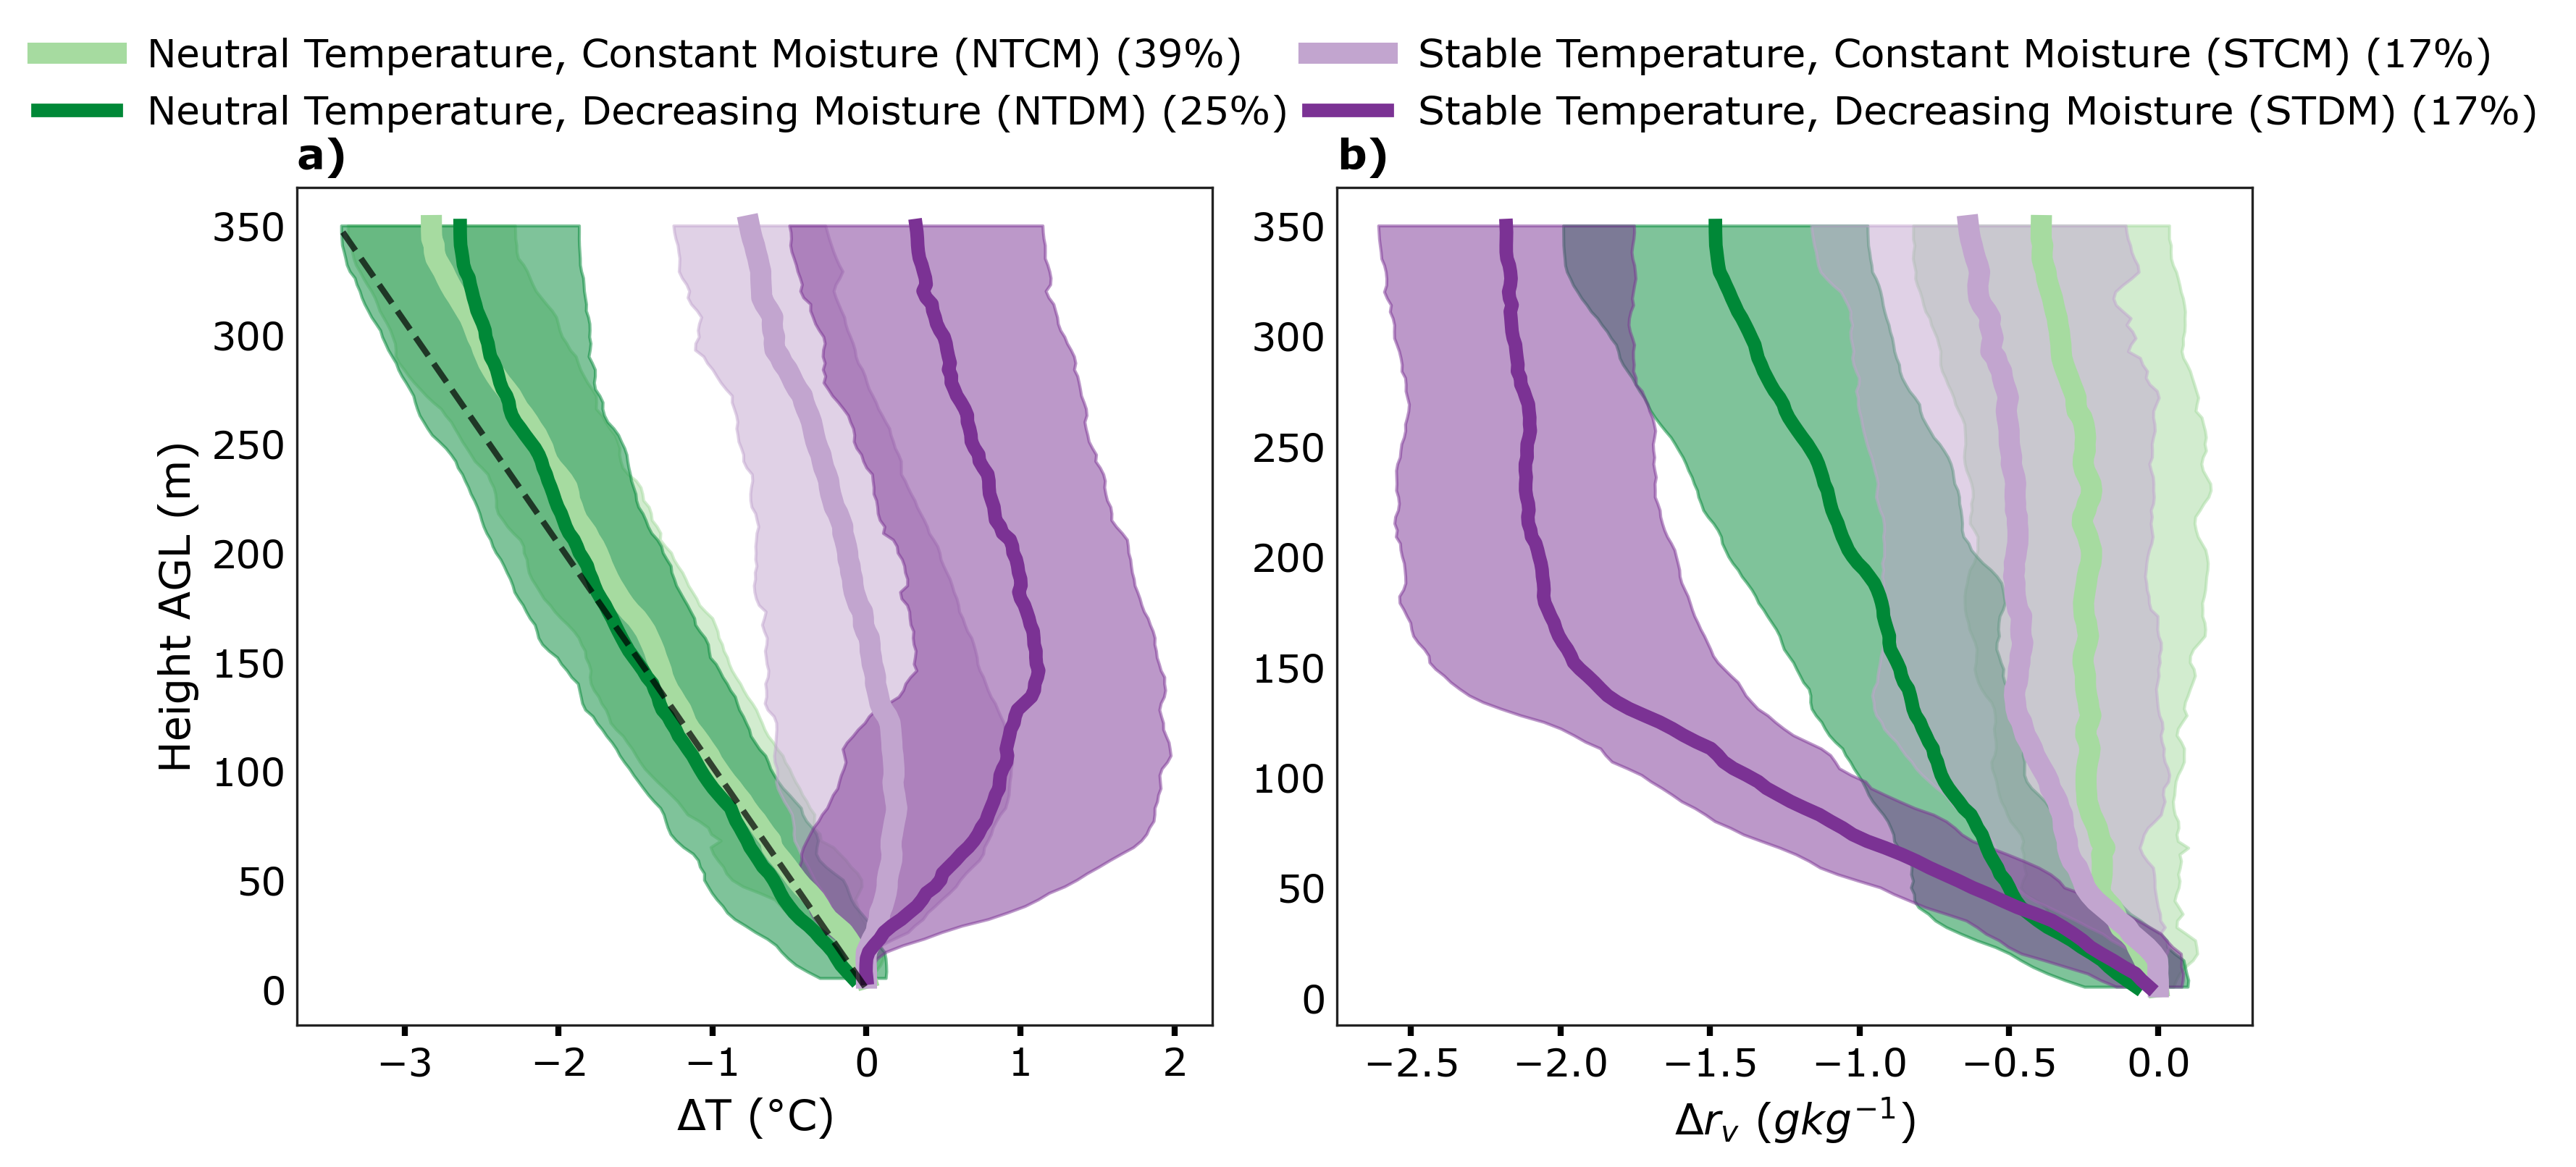

In [22]:
y = np.arange(1,351)
x = y*(-9.8*10**-3)
x2=0*y
matplotlib.rc('xtick', labelsize=13) 
matplotlib.rc('ytick', labelsize=13)
method_titles = [ "dT+dMR minmax"]
k_lbls = [ "k_lbl_MR_minmax"]
clusters_order = [0,2,3,1]
clusters_labels = ["Neutral Temperature, Constant Moisture (NTCM)",
                  "Neutral Temperature, Decreasing Moisture (NTDM)",
                   "Stable Temperature, Constant Moisture (STCM)",
                   "Stable Temperature, Decreasing Moisture (STDM)",
                  ]

for m in range(len(k_lbls)):
    colors = ['#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494','#081d58']
    fig,axes = plt.subplots(1,2,figsize = (10,5), facecolor = "white")
    k_lbl =  k_lbls[m]
    for index,ii in enumerate(clusters_order):
        ax = axes[0]
        ax2 = axes[1]
        if ii == 0 or ii ==3:
            lstyle = "solid"
            lwidth = 7
        else:
            lstyle = "solid"
            lwidth = 4.5
        df_now = dT_df[dT_df[k_lbl]==ii]
        df_now_MR = dMR_df[dMR_df[k_lbl]==ii]

        pct = int(len(df_now)/len(dT_df)*100)
        pct_MR = int(len(df_now_MR)/len(dMR_df)*100)
        T_mean =  df_now.iloc[:,5:].mean().values
        T_sd = df_now.iloc[:,5:].std().values
        MR_mean =  df_now_MR.iloc[:,5:].mean().values
        MR_sd = df_now_MR.iloc[:,5:].std().values

        ax.plot(T_mean,z_interp, label = f"{clusters_labels[index]} ({pct}%)", color = cluster_colors[ii], 
                linestyle = lstyle, linewidth = lwidth)
        ax.fill_betweenx(z_interp, T_mean-T_sd, T_mean+T_sd, color = cluster_colors[ii],alpha=0.5)
        ax2.plot(MR_mean,z_interp, color = cluster_colors[ii], 
                 linestyle = lstyle, linewidth = lwidth)
        ax2.fill_betweenx(z_interp, MR_mean-MR_sd, MR_mean+MR_sd, color = cluster_colors[ii],alpha=0.5)

    fig.legend(bbox_to_anchor=(1.13, 1.089),ncols = 2,columnspacing = 0.5, fontsize = 13)

    ax.plot(x,y, linestyle = '--', color = 'k', alpha = 0.7)
    ax.set_ylabel(r"Height AGL (m)", fontweight = "normal", fontsize = 14)

    ax.set_xlabel(r"$\Delta$T ($\degree$C)", fontweight = "normal", fontsize = 14)
    ax2.set_xlabel(r"$\Delta$$r_v$ ($g kg^{-1}$)", fontweight = "normal", fontsize = 14)
    ax.set_title("a)", fontsize = 14)
    ax2.set_title("b)", fontsize = 14)
    # ax.invert_yaxis()
    # plt.title(method_titles[m])
    plt.savefig(f"{figPath}fig2_08182026_2.png")
    plt.show()
    plt.close()

### Now output csv for labeling profiles 

In [87]:
T_log_list = []
km_log_list_zscore = []
km_log_list_minmax = []
T_interp_list = []
# for i in range(len(log)):
for count,leg in enumerate(log["Unnamed: 0"].values):
    # temp_log = log.iloc[i]
    # print(temp_log)
    # print(dT_df[dT_df["leg_index"] == i].index)
    # print(leg)
    index_T_km = dT_df[dT_df["leg_index"] == leg].index
    # print(index_T_km)
    if not index_T_km.empty:
        T_log_list.append(index_T_km)
        # km_log_list_zscore.extend(dT_df["k_lbl_MR_zscore"].iloc[index_T_km].values)
        km_log_list_minmax.extend(dT_df["k_lbl_MR_minmax"].iloc[index_T_km].values)
    else:
        T_log_list.append(np.nan)
        km_log_list_zscore.append(np.nan)
        km_log_list_minmax.append(np.nan)
    # index_T_interp = T_df_interp[T_df_interp["Unnamed: 0"]==i].index
# log["5cluster_zscore"] = km_log_list_zscore
log["4cluster_minmax_CPonly_mode1_zonly"] = km_log_list_minmax

In [65]:
log

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,index,Date,IOP,Type,Flight,profid,starttime,...,dwspeed,duv,dBZ,LCL,PW,Sfc-3km_LR,VPD,Sfc-350m_LR,Sfc-LCL_LR,4cluster_minmax_CPonly_mode1_zonly
0,28,28,28,0,2023-05-27,17,ascending,3,0.0,2023-05-27 23:22:26,...,-0.54,11.84,65.0,1092.0,0.47,8.7,6.63,13.17,5.68,1.0
1,29,29,29,1,2023-05-27,17,ascending,3,1.0,2023-05-27 23:26:22,...,0.70,12.36,65.0,1092.0,0.47,8.7,6.63,13.17,5.68,1.0
2,30,30,30,0,2023-05-27,17,descending,3,0.0,2023-05-27 23:24:25,...,-0.96,10.92,65.0,1092.0,0.47,8.7,6.63,13.17,5.68,1.0
3,31,31,31,1,2023-05-27,17,descending,3,1.0,2023-05-27 23:28:17,...,-0.51,11.36,65.0,1092.0,0.47,8.7,6.63,13.17,5.68,1.0
4,48,48,48,0,2023-05-30,18,ascending,3,0.0,2023-05-30 22:57:27,...,-2.82,2.92,45.0,1850.0,0.49,9.6,10.71,15.36,9.11,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,371,371,371,2,2023-06-21,27,ascending,2,2.0,2023-06-21 22:12:24,...,3.93,9.89,70.0,886.0,0.96,9.0,5.47,16.00,11.65,2.0
198,372,372,372,3,2023-06-21,27,ascending,2,3.0,2023-06-21 22:16:23,...,6.30,11.70,70.0,886.0,0.96,9.0,5.47,16.00,11.65,NaN
199,373,373,373,0,2023-06-21,27,descending,2,0.0,2023-06-21 22:06:22,...,0.08,5.87,70.0,886.0,0.96,9.0,5.47,16.00,11.65,2.0
200,374,374,374,1,2023-06-21,27,descending,2,1.0,2023-06-21 22:10:23,...,2.67,9.23,70.0,886.0,0.96,9.0,5.47,16.00,11.65,2.0


In [88]:
log.to_csv(f"{dataPath}/prof_log_v16_airdata_id_v3_kmeans_clusters_v16_combo_mode1_zonly.csv")